# YZ50 — Week 4: MLP Language Model

- A **neural network language model** predicts the next character by using a fixed **context window** of previous characters instead of relying on a simple bigram table.

- Each character is represented by a learnable **embedding vector**. The embeddings of the previous three characters are combined and passed through an **MLP (Multilayer Perceptron)** to predict the next character.

- The model is trained using **minibatches** and **gradient descent**, with the data divided into **train / dev / test sets** to evaluate its ability to generalize to unseen data.

- The model's performance is evaluated using **cross-entropy loss**, which measures how well the predicted probability distribution matches the target characters.

In this part, I build the **MLP language model** from scratch, train it on a character-level dataset, and analyze how **context size, embedding dimensions, and model capacity** affect its performance.

# Continuing to Build Makemore: Character-Level Language Model with MLP

---

For this setup, the learnable parameters are the **weights (W)**, **biases (b)**, and the **embedding lookup table (C)**. All of them are updated through backpropagation and gradient descent to minimize the loss.


# 1. Part 2 ile başla. Önceki üç harfi bağlam alan veri setini kur (X: 3 harf indeksi, Y: sıradaki harf). Embedding tablosunu (27x2) oluştur indeksleme ile embedding'leri çek.

In [1869]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import pandas as pd


In [1870]:
# read in all the words
words = open('../data/names.txt', 'r').read().splitlines() # # Read the names from the file and split them into a list
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [1871]:
len(words)

32033

## 1.1 Create the lookup tables

In [1872]:
# build the vocabulary of characters and mappings to/from integers
# Create a lookup table to map characters to indices (0-25 for 'a'-'z', 26 for start/end tokens)
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


## 1.2 Construct the dataset

In [1873]:
# build the dataset

block_size = 3 # context length: how many characters do we take to predict the next one?
X, Y = [], [] # X is the input data (context) for the neural network, Y is the target data (next character) for each input context
for w in words[:5]:

  print(w)
  context = [0] * block_size # initialize the context with zeros (start tokens)
  for ch in w + '.':
    ix = stoi[ch]
    X.append(context)
    Y.append(ix)
    print(''.join(itos[i] for i in context), '--->', itos[ix])
    context = context[1:] + [ix] # update the context by removing the first character and adding the new character, this works like a sliding window
    #print('context:', context)

X = torch.tensor(X)
Y = torch.tensor(Y)

# For each word, it creates a context of length `block_size` (initialized with zeros) and iterates through each character in the word (plus a period to indicate the end of the word). For each character, it appends the current context to `X` and the index of the character to `Y`. After processing each character, it updates the context by removing the first character and adding the new character, effectively creating a sliding window of context for predicting the next character.

emma
... ---> e
..e ---> m
.em ---> m
emm ---> a
mma ---> .
olivia
... ---> o
..o ---> l
.ol ---> i
oli ---> v
liv ---> i
ivi ---> a
via ---> .
ava
... ---> a
..a ---> v
.av ---> a
ava ---> .
isabella
... ---> i
..i ---> s
.is ---> a
isa ---> b
sab ---> e
abe ---> l
bel ---> l
ell ---> a
lla ---> .
sophia
... ---> s
..s ---> o
.so ---> p
sop ---> h
oph ---> i
phi ---> a
hia ---> .


In [1874]:
X.shape, X.dtype, Y.shape, Y.dtype

(torch.Size([32, 3]), torch.int64, torch.Size([32]), torch.int64)

### Function for splitted dataset

In [1875]:
# build the dataset
def build_dataset(words):
  block_size = 3
  X, Y = [], []
  for w in words:

    #print(w)
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      #print(''.join(itos[i] for i in context), '--->', itos[ix])
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


## 1.3 Create the embeddings, embedding lookup table C

In [1876]:
# Create the embedding table `C` with random values.
C = torch.randn((27,2)) # 27 rows for each character in the vocabulary (26 letters + 1 for the period), and 2 columns for the embedding dimension. Each row corresponds to a character's embedding vector.

In [1877]:
C

tensor([[ 1.0756,  1.2781],
        [ 0.6576,  1.6215],
        [-1.5820, -0.0757],
        [-0.4111, -0.5951],
        [ 1.7460,  0.0194],
        [ 0.0570,  0.1364],
        [-0.7695, -0.0596],
        [-0.2352, -0.0237],
        [ 0.5724, -0.9074],
        [ 0.6642, -0.4803],
        [-0.8609, -0.6397],
        [ 2.0449, -1.8818],
        [-0.1264, -0.7787],
        [-0.5831, -1.7105],
        [-2.0893,  0.0523],
        [ 0.3098,  1.4995],
        [-0.8243, -0.5110],
        [ 2.1680, -0.8094],
        [-1.3317, -0.5771],
        [ 0.5125, -0.3853],
        [ 1.1125, -0.9107],
        [ 1.1932, -0.7634],
        [-2.1312, -0.8346],
        [-1.1816, -0.5439],
        [-2.7369,  0.6590],
        [-0.1335, -0.9125],
        [ 0.4523, -0.0086]])

In [1878]:
C[5] # much faster than doing one-hot encoding and matrix multiplication, but we will do that next to show that it is equivalent

tensor([0.0570, 0.1364])

In [1879]:
F.one_hot(torch.tensor(5), num_classes=27).float() @ C # this is the same as C[5]

tensor([0.0570, 0.1364])

In [1880]:
C[torch.tensor([5, 0, 2])] # this gives us the embeddings for the characters with indices 5, 0, and 2

tensor([[ 0.0570,  0.1364],
        [ 1.0756,  1.2781],
        [-1.5820, -0.0757]])

In [1881]:
X[2] # this gives us the indices of the characters in the context of the 3rd training example (index 2)

tensor([ 0,  5, 13])

In [1882]:
C[X[2]] # this gives us the embeddings for the characters in the context of the 3rd training example (index 2)

tensor([[ 1.0756,  1.2781],
        [ 0.0570,  0.1364],
        [-0.5831, -1.7105]])

In [1883]:
C[X] # this is the same as doing one-hot encoding and matrix multiplication for all the indices in X

tensor([[[ 1.0756,  1.2781],
         [ 1.0756,  1.2781],
         [ 1.0756,  1.2781]],

        [[ 1.0756,  1.2781],
         [ 1.0756,  1.2781],
         [ 0.0570,  0.1364]],

        [[ 1.0756,  1.2781],
         [ 0.0570,  0.1364],
         [-0.5831, -1.7105]],

        [[ 0.0570,  0.1364],
         [-0.5831, -1.7105],
         [-0.5831, -1.7105]],

        [[-0.5831, -1.7105],
         [-0.5831, -1.7105],
         [ 0.6576,  1.6215]],

        [[ 1.0756,  1.2781],
         [ 1.0756,  1.2781],
         [ 1.0756,  1.2781]],

        [[ 1.0756,  1.2781],
         [ 1.0756,  1.2781],
         [ 0.3098,  1.4995]],

        [[ 1.0756,  1.2781],
         [ 0.3098,  1.4995],
         [-0.1264, -0.7787]],

        [[ 0.3098,  1.4995],
         [-0.1264, -0.7787],
         [ 0.6642, -0.4803]],

        [[-0.1264, -0.7787],
         [ 0.6642, -0.4803],
         [-2.1312, -0.8346]],

        [[ 0.6642, -0.4803],
         [-2.1312, -0.8346],
         [ 0.6642, -0.4803]],

        [[-2.1312, -0

In [1884]:
C[X].shape # (number of training examples, block_size, embedding dimension)

torch.Size([32, 3, 2])

In [1885]:
emb = C[X]
emb.shape

torch.Size([32, 3, 2])

# 2. Gizli katmanı ve çıkış katmanını kur: embedding'leri düzleştir, W1 ve b1 ile tanh, W2 ve b2 ile logits. Loss'u geçen haftaki gibi elle hesapla, sonra F.cross_entropy ile aynı sonucu aldığını göster ve neden onu tercih ettiğimizi videodan anla.

## 2.1 Construct the hidden layer

In [1886]:
W1 = torch.randn((6, 100)) # 6 input features (3 characters * 2 embedding dimensions) and 100 output features (hidden layer size)
B1 = torch.randn(100) # bias for the hidden layer

In [1887]:
# Basicly what we want to do is this
# W1 @ emb + B1
# But the emb is 3D and the W1 is 2D, so we need to reshape the emb to be 2D as well. We can do this by using the view method to flatten the last two dimensions of emb into a single dimension. This will give us a 2D tensor with shape (number of training examples, block_size * embedding dimension). Then we can do the matrix multiplication with W1 and add B1.

# Why Do We Concatenate Embeddings Before the Hidden Layer?

Suppose our input has:

* `batch_size = 32`
* `block_size = 3` characters
* `embedding_dim = 2`

After the embedding lookup, our tensor has the shape:

```python
(32, 3, 2)
```

This means:

```text
32 training examples
3 characters per example
2-dimensional embedding for each character
```

For example, one training example might look like:

```text
[
    [0.2, 0.5],    # character 1
    [0.1, -0.3],   # character 2
    [0.7, 0.8]     # character 3
]
```

## Why do we reshape it?

Our first hidden layer is defined as:

```python
W1 = torch.randn((6, 100))
B1 = torch.randn(100)
```

The `6` comes from:

```text
block_size × embedding_dim
= 3 × 2
= 6
```

So we transform:

```text
(batch_size, block_size, embedding_dim)
```

into:

```text
(batch_size, block_size * embedding_dim)
```

In our example:

```text
(32, 3, 2)
    ↓
(32, 6)
```

The embeddings are not reduced or lost. We are simply putting the embeddings of the three characters next to each other:

```text
[0.2, 0.5] + [0.1, -0.3] + [0.7, 0.8]

        ↓

[0.2, 0.5, 0.1, -0.3, 0.7, 0.8]
```

Now each training example is represented by a single 6-dimensional feature vector.

## Why do we need this?

Because we want the hidden layer to consider **all three characters together**.

The matrix multiplication is:

```text
X       @       W1       +       B1
(32,6)      (6,100)            (100,)

                ↓

             (32,100)
```

Therefore:

```python
hidden = X @ W1 + B1
```

The hidden layer receives information from all three characters simultaneously.

For example:

```text
character 1 ─┐
character 2 ─┼──→ concatenate → Linear(6, 100) → hidden layer
character 3 ─┘
```

## Important: We are NOT reducing the embedding dimension

* We are not reducing the embeddings; we are simply putting the 3 embeddings into one feature vector so the hidden layer can process the entire context together.

## In short

```text
Embedding output:

(batch_size, block_size, embedding_dim)
              ↓
            reshape
              ↓
(batch_size, block_size × embedding_dim)
              ↓
        Linear layer
              ↓
(batch_size, hidden_size)
```

For our example:

```text
(32, 3, 2)
    ↓
(32, 6)
    ↓
Linear(6, 100)
    ↓
(32, 100)
```

The main reason is:

> **We concatenate the embeddings so that the hidden layer can process the entire context window as one feature vector and learn interactions between all characters.**


In [1888]:
h = torch.tanh(emb.view(-1, 6) @ W1 + B1) # flatten the last two dimensions of emb into a single dimension and do the matrix multiplication with W1 and add B1

In [1889]:
h # (number of training examples, hidden layer size)

tensor([[ 0.9816, -0.9995, -0.9787,  ..., -0.9999,  0.9203,  1.0000],
        [ 0.3974, -0.9972, -0.8760,  ..., -0.9997, -0.7173,  0.9999],
        [-0.9235, -0.9874,  0.9755,  ..., -0.9724, -0.9785,  0.9132],
        ...,
        [ 0.1801, -0.9953,  0.9982,  ..., -0.9882,  0.5854,  0.9238],
        [ 0.9020, -0.7943,  0.9877,  ...,  0.9961, -0.9855, -0.8497],
        [ 0.9998,  0.5302,  0.6633,  ...,  0.9175,  0.9931,  0.9869]])

In [1890]:
h.shape # (number of training examples, hidden layer size)

torch.Size([32, 100])

## 2.2 Create the output layer

In [1891]:
W2 = torch.randn((100, 27)) # 100 input features (hidden layer size) and 27 output features (number of characters in the vocabulary)
B2 = torch.randn(27) # bias for the output layer

In [1892]:
logits = h @ W2 + B2 # (number of training examples, number of characters in the vocabulary)

In [1893]:
logits.shape # (number of training examples, number of characters in the vocabulary)

torch.Size([32, 27])

In [1894]:
counts = logits.exp() # apply the exponential function to the logits to get unnormalized probabilities
probs = counts / counts.sum(1, keepdims=True) # normalize the probabilities by dividing by the sum of each row

In [1895]:
probs.shape # (number of training examples, number of characters in the vocabulary)

torch.Size([32, 27])

## 2.3 Create the loss function.

In [1896]:
loss = -probs[torch.arange(32), Y].log().mean() # negative log likelihood loss, we take the log of the probabilities of the correct characters and take the mean over all training examples
loss

tensor(11.5905)

## Back from Scratch

In [1897]:
X.shape, Y.shape # dataset

(torch.Size([32, 3]), torch.Size([32]))

In [1898]:
g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((27, 2), generator=g)
W1 = torch.randn((6, 100), generator=g)
b1 = torch.randn(100, generator=g)
W2 = torch.randn((100, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [1899]:
sum(p.nelement() for p in parameters) # number of parameters in total

3481

In [1900]:
# Forward pass
emb = C[X] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
#counts = logits.exp()
#prob = counts / counts.sum(1, keepdims=True)
#loss = -prob[torch.arange(32), Y].log().mean()
loss = F.cross_entropy(logits, Y) # this is the same as the loss we calculated above, but it is more numerically stable and efficient
loss

tensor(17.7697)

## Why Use `F.cross_entropy`?

Instead of manually calculating:

```python
counts = logits.exp()
prob = counts / counts.sum(1, keepdims=True)
loss = -prob[torch.arange(32), Y].log().mean()
```

we use:

```python
loss = F.cross_entropy(logits, Y)
```

### Why?

1. **More efficient:** It combines the operations internally, using less memory and computation.

2. **Better backward pass:** PyTorch can optimize the gradient computation by combining the operations, making backpropagation more efficient.

3. **Numerically more stable:** It avoids explicitly computing `exp()` and probabilities, reducing the risk of numerical overflow/underflow.


# 3. Eğitim döngüsünü kur: önce tek bir minibatch'i overfit et, sonra bütün veriyi minibatch'lerle eğit. Learning rate'i videodaki gibi tara ve iyi bir değer seç. Veriyi train / dev / test olarak böl, loss'u dev üzerinde raporla.

## 3.1 Construct the full dataset

In [1712]:
# build the full dataset
block_size = 3
X, Y = [], []
for w in words:
  #print(w)
  context = [0] * block_size
  for ch in w + '.':
    ix = stoi[ch]
    X.append(context)
    Y.append(ix)
    #print(''.join(itos[i] for i in context), '--->', itos[ix])
    context = context[1:] + [ix]
X = torch.tensor(X)
Y = torch.tensor(Y)

In [1713]:
X.shape, Y.shape # dataset

(torch.Size([228146, 3]), torch.Size([228146]))

In [1714]:
for p in parameters:
  p.requires_grad = True

## 3.2 Finding best Learning rate

In [1715]:
# Candidate learning rates
lre = torch.linspace(-3, 0, 1000) # log10 learning rates
lrs = 10**lre

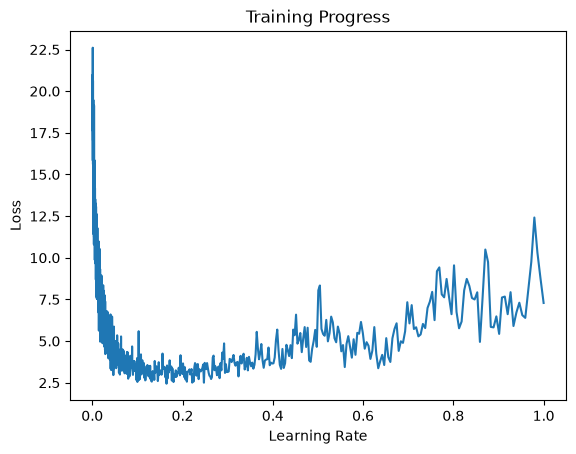

Best learning rate: 0.165


In [1716]:
# Function to find the best learning rate by training the model for a few iterations with different learning rates and plotting the loss against the learning rate. The learning rate that gives the lowest loss is considered the best learning rate.
# Without changing the original parameters, we will create independent copies of the parameters and train the model for a few iterations with different learning rates. We will then plot the loss against the learning rate and find the learning rate that gives the lowest loss.
def find_lr(lrs, X=X, Y=Y, C=C, W1=W1, b1=b1, W2=W2, b2=b2):
    # Create independent copies
    C = C.detach().clone().requires_grad_(True)
    W1 = W1.detach().clone().requires_grad_(True)
    b1 = b1.detach().clone().requires_grad_(True)
    W2 = W2.detach().clone().requires_grad_(True)
    b2 = b2.detach().clone().requires_grad_(True)

    parameters = [C, W1, b1, W2, b2]

    lri = []
    lossi = []

    for i in range(1000):
        ix = torch.randint(0, X.shape[0], (32,))

        # forward pass
        emb = C[X[ix]]
        h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
        logits = h @ W2 + b2
        loss = F.cross_entropy(logits, Y[ix])

        # backward pass
        for p in parameters:
            p.grad = None
        loss.backward()

        # update
        lr = lrs[i]
        for p in parameters:
            p.data += -lr * p.grad

        lri.append(lr)
        lossi.append(loss.item())

    plt.plot(lri, lossi)
    plt.xlabel('Learning Rate')
    plt.ylabel('Loss')
    plt.title('Training Progress')
    plt.show()

    best_lr = lri[lossi.index(min(lossi))]
    print(f'Best learning rate: {best_lr:.3f}')

    return best_lr

lr = find_lr(lrs, X=X, Y=Y, C=C, W1=W1, b1=b1, W2=W2, b2=b2)


## Finding the Best Learning Rate

The learning rate controls **how large each parameter update is** during training.

* If it is **too small**, training becomes unnecessarily slow.
* If it is **too large**, the loss may become unstable or even diverge.
* Therefore, finding a good learning rate is important for **fast and stable training**.

### Method

We test many learning rates between:

```python
10^-3 and 10^0
```

using logarithmically spaced values:

```python
lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre
```

For each learning rate, we train the model for a number of mini-batch iterations and record the loss.

Then we plot:

```text
Learning Rate → Loss
```

and choose the learning rate that produces the **lowest loss**.

The original model parameters are kept unchanged by using independent copies inside `find_lr()`.


In [1717]:
for i in range(1000):
  # Mini-batch construction
  ix = torch.randint(0, X.shape[0], (32,)) # randomly select 32 indices from the dataset

  # forward pass
  emb = C[X[ix]] 
  h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (32, 100)
  logits = h @ W2 + b2 # (32, 27)
  loss = F.cross_entropy(logits, Y[ix])
  #print(loss.item())

  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()

  # update
  for p in parameters:
    p.data += -lr * p.grad

In [1718]:
emb = C[X[ix]]
h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Y[ix])
loss

tensor(2.4919, grad_fn=<NllLossBackward0>)

## Why Use Mini-Batches?

Instead of calculating the loss using the **entire dataset** at every step, we randomly select a small batch of 32 examples:

```python
ix = torch.randint(0, X.shape[0], (32,))
```

### Why?

1. **Faster:** We perform each update using only 32 examples instead of the entire dataset.

2. **Less memory:** We don't need to store and process the whole dataset during each forward/backward pass.

3. **More frequent updates:** We can update the parameters much more often, which usually makes training faster.

4. **Useful noise:** Random batches give slightly noisy gradient estimates, which can help the model explore the loss landscape instead of following one exact gradient path.

* We don't calculate the exact gradient of the entire dataset. Instead, the gradient calculated from a small random mini-batch is an approximation of the true gradient. Even though it is not exact, it is usually a good enough direction for updating the parameters and training the model efficiently.

## 3.3 Split the dataset into train/dev/test


## Why Do We Split the Dataset?

If we use the **same data for training and evaluation**, the model may **overfit**: instead of learning general patterns, it can memorize the training examples.

By splitting the data, we can check whether the model has actually learned patterns that **generalize to unseen data**.

## Train, Development, and Test Split

We split the dataset into three parts:

```text
80% → Training set
10% → Development / Validation set
10% → Test set
```

* **Training set:** Used to update the model's **parameters** (weights and biases).

* **Development / Validation set:** Used to evaluate the model during development and choose **hyperparameters**, such as the learning rate and model architecture.

* **Test set:** Used only at the end to **evaluate the final model** on completely unseen data.

This separation helps us measure how well the model **generalizes instead of memorizes**.


In [1719]:
# train split, developement/validation split, test split
#     %80                  %10                    %10

In [1720]:
Xtr.shape, Ytr.shape # dataset

(torch.Size([182625, 3]), torch.Size([182625]))

In [1721]:
# Reset the Network
g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((27, 2), generator=g)
W1 = torch.randn((6, 100), generator=g)
b1 = torch.randn(100, generator=g)
W2 = torch.randn((100, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [1722]:
sum(p.nelement() for p in parameters) # number of parameters in total

3481

In [1723]:
for p in parameters:
  p.requires_grad = True

### 3.3.1 Train

In [1724]:
lossi = []
stepi = []

for i in range(10000):
  # Mini-batch construction
  ix = torch.randint(0, Xtr.shape[0], (32,)) # randomly select 32 indices from the dataset

  # forward pass
  emb = C[Xtr[ix]]
  h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (32, 100)
  logits = h @ W2 + b2
  loss = F.cross_entropy(logits, Ytr[ix])
  #print(loss.item())

  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()

  # update
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  lossi.append(loss.item())
  stepi.append(i)

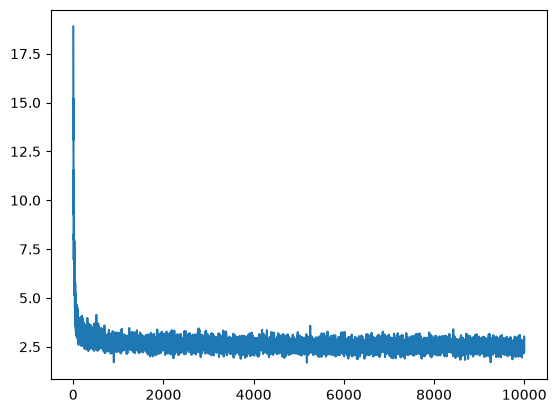

In [1725]:
plt.plot(stepi, lossi)

In [1726]:
# Train Loss
emb = C[Xtr]
h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Ytr)
loss

tensor(2.5043, grad_fn=<NllLossBackward0>)

### 3.3.2 Developement / Validation

In [1727]:
# Development Loss
emb = C[Xdev]
h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.5006, grad_fn=<NllLossBackward0>)

## Interpreting Train and Development Loss

After training, we compare the **train loss** and **development loss**:

* **Both low and close to each other** → The model is learning well and generalizing.
* **Train loss low, dev loss much higher** → The model is likely **overfitting**.
* **Both losses high** → The model may be **underfitting** or not learning effectively.
* It is normal for the **dev loss to be slightly higher** than the train loss.

The main goal is to have a **low dev loss**, because it shows how well the model performs on unseen data.


# 4. Gizli katmanı ve embedding boyutunu büyütüp dev loss'un nasıl değiştiğini göster. Embedding'leri 2 boyutta çizdir: hangi harfler birbirine yakın düşüyor? Modelden isimler örnekle, bigram'ınkilerle karşılaştır.

## 4.1 Increase the number of hidden layer neurons.

In [1837]:
# Reset the Network
g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((27, 2), generator=g)
W1 = torch.randn((6, 300), generator=g)
b1 = torch.randn(300, generator=g)
W2 = torch.randn((300, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [1838]:
sum(p.nelement() for p in parameters) # number of parameters in total

10281

In [1839]:
for p in parameters:
  p.requires_grad = True

In [ ]:
lossi = []
stepi = []

for i in range(30000):
  # Mini-batch construction
  ix = torch.randint(0, Xtr.shape[0], (32,)) # randomly select 32 indices from the dataset

  # forward pass
  emb = C[Xtr[ix]]
  h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (32, 300)
  logits = h @ W2 + b2
  loss = F.cross_entropy(logits, Ytr[ix])
  #print(loss.item())

  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()

  # update
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  lossi.append(loss.item())
  stepi.append(i)

In [ ]:
# Train Loss
emb = C[Xtr]
h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (32, 300)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Ytr)
loss

tensor(2.5175, grad_fn=<NllLossBackward0>)

In [ ]:
# Development Loss
emb = C[Xdev]
h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (32, 300)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.5051, grad_fn=<NllLossBackward0>)

## 4.2 Visualize embeddings in 2D

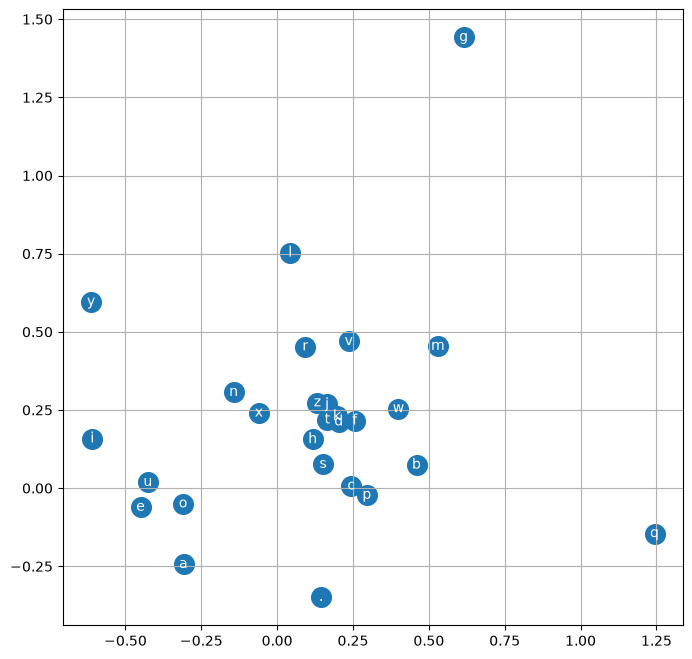

In [1750]:
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha="center", va="center", color='white')
plt.grid('minor')

## 4.3 Increase the embedding dimension alongside the number of hidden layer neurons.

In [1856]:
# Reset the Network
g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((27, 10), generator=g)
W1 = torch.randn((30, 200), generator=g)
b1 = torch.randn(200, generator=g)
W2 = torch.randn((200, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [1857]:
sum(p.nelement() for p in parameters) # number of parameters in total

11897

In [1858]:
for p in parameters:
  p.requires_grad = True

In [1859]:
lossi = []
stepi = []

In [1861]:
for i in range(100000):
  # Mini-batch construction
  ix = torch.randint(0, Xtr.shape[0], (32,)) # randomly select 32 indices from the dataset

  # forward pass
  emb = C[Xtr[ix]]
  h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
  logits = h @ W2 + b2
  loss = F.cross_entropy(logits, Ytr[ix])
  #print(loss.item())

  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()


  lr_optimized = (
    lr if i < 10000 else
    lr * 0.5 if i < 30000 else
    lr * 0.1
  )
  # update
  for p in parameters:
    p.data += -lr_optimized * p.grad

  # track stats
  lossi.append(loss.log10().item())
  stepi.append(i)

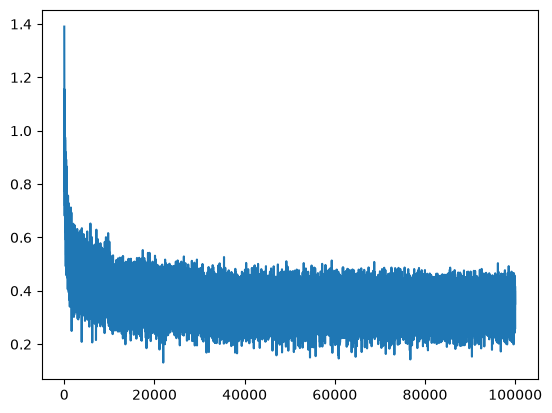

In [1862]:
plt.plot(stepi, lossi)

In [1863]:
# Train Loss
emb = C[Xtr]
h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 200)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Ytr)
loss

tensor(2.2037, grad_fn=<NllLossBackward0>)

In [1864]:
# Development Loss
emb = C[Xdev]
h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 300)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.2224, grad_fn=<NllLossBackward0>)

## 4.4 Sample from the model

In [1868]:
# Sample names from the neural network model
g = torch.Generator().manual_seed(2147483647 + 10)

model_names = []

for _ in range(20):
    out = []
    context = [0] * block_size

    while True:
        emb = C[torch.tensor([context])]
        h = torch.tanh(emb.view(1, -1) @ W1 + b1)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0:
            break
    name = ''.join(itos[i] for i in out)
    model_names.append(name)


# Bigram model names
bigram_names = [
    "cexze", "momasurailezitynn", "konimittain", "llayn",
    "ka", "d", "staiyaubrtthrigotai", "moliellavo",
    "ke", "teda", "ka", "emimmsade", "enkaviyny",
    "ftlspihinivenvorhlasu", "dsor", "br", "jol", "pen",
    "aisan", "ja"
]

# Comparison table
df = pd.DataFrame({
    "Neural Network": model_names,
    "Bigram": bigram_names
})

df

,Neural Network,Bigram
0,carmah.,cexze
1,amori.,momasurailezitynn
2,rihlinleige.,konimittain
3,tyr.,llayn
4,kansh.,ka
5,emmahnen.,d
6,den.,staiyaubrtthrigotai
7,rha.,moliellavo
8,areen.,ke
9,nermara.,teda
